In [19]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore")

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [2]:
sgr_df = pickle.load(open('sgr_set_resnet','rb')) 
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-2 dataset

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.999657
2944,0.0,0.0,0.999708
2024,1.0,1.0,0.999928
263,0.0,0.0,0.999928
4350,0.0,0.0,0.997041


In [3]:
delta = 0.001
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds
metric_targets=[i/1000 for i in integers_exp_spacing(5,300)]
proportions_1 = np.linspace(0.01,0.5,15) # for classes imbalance impact study

In [4]:
train_set = sgr_df.iloc[:2*int(len(sgr_df)/3)]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[2*int(len(sgr_df)/3):]

## <font color = 'yellow'> 1. __0/1 standard risk control__ 
Dichotomy search for upper bound

#### <font color = 'violet'> 1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.004989,0.936391,0.001985,0.971925,0.001325,0.970009
1,0.006,0.005879,0.864528,0.002615,0.983498,0.003483,0.984147
2,0.007,0.006773,0.811749,0.003257,0.986927,0.003905,0.987575
3,0.008,0.007936,0.771896,0.004116,0.989284,0.004762,0.989717
4,0.009,0.009059,0.708908,0.004969,0.992070,0.005188,0.991003
5,0.010,0.010161,0.657958,0.005821,0.993999,0.005611,0.992716
6,0.011,0.010982,0.638820,0.006464,0.994642,0.005608,0.993145
7,0.013,0.013112,0.578538,0.008165,0.997428,0.006457,0.995287
8,0.016,0.013612,0.510480,0.008574,0.999786,0.009001,0.999572
9,0.018,0.013612,0.510480,0.008574,0.999786,0.009001,0.999572


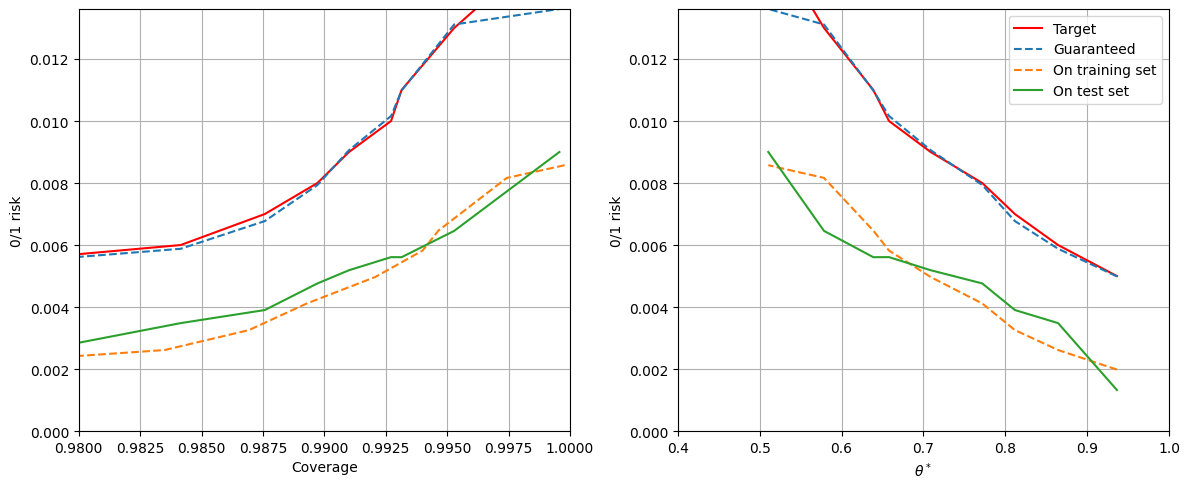

In [5]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         mode='dicho')
display(results)
metric_plots(results, ylabel='0/1 risk', xlim1=[0.98,1], xlim2=[0.4,1], ylim=[0,max(results.metric_bound)])

__Comment__ : 

At 100% coverage one can observe 1- the classifier accuracy

#### <font color = 'violet'> 1.2. Evolution of trade-offs as class imbalance increases

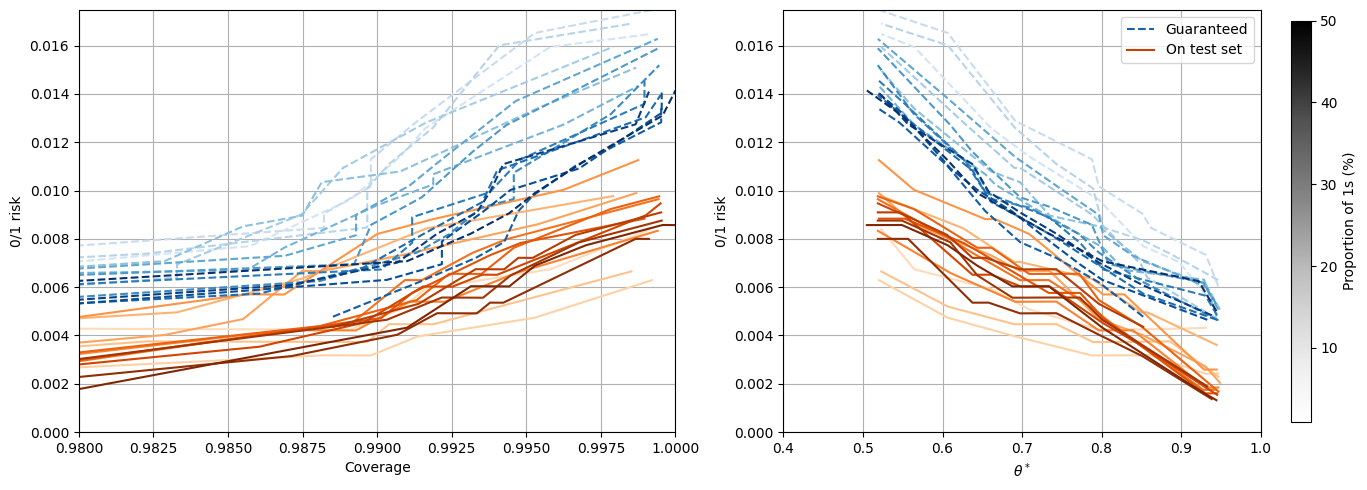

In [ ]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='dicho', metric='standard')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='0/1 risk', xlim1= [0.98, 1], xlim2= [0.4, 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)])

__Comment__ : here one can observe that
* risk-coverage curves do not really change as class imbalance increases

## <font color = 'yellow'> 2. __FN/FP proportions control__
Dichotomy search for upper bound

### <font color = 'orange'> 2.1. __FP proportion control__

#### <font color = 'violet'> 2.1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.005206,0.708908,0.002160,0.992070,0.003026,0.991003
1,0.006,0.005823,0.679526,0.002590,0.993142,0.003024,0.991859
2,0.007,0.006718,0.626485,0.003231,0.995071,0.003450,0.993573
3,0.008,0.008149,0.556714,0.004293,0.998500,0.003868,0.997001
4,0.009,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572
5,0.010,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572
6,0.011,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572
7,0.013,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572
8,0.016,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572
9,0.018,0.008139,0.510480,0.004287,0.999786,0.004286,0.999572


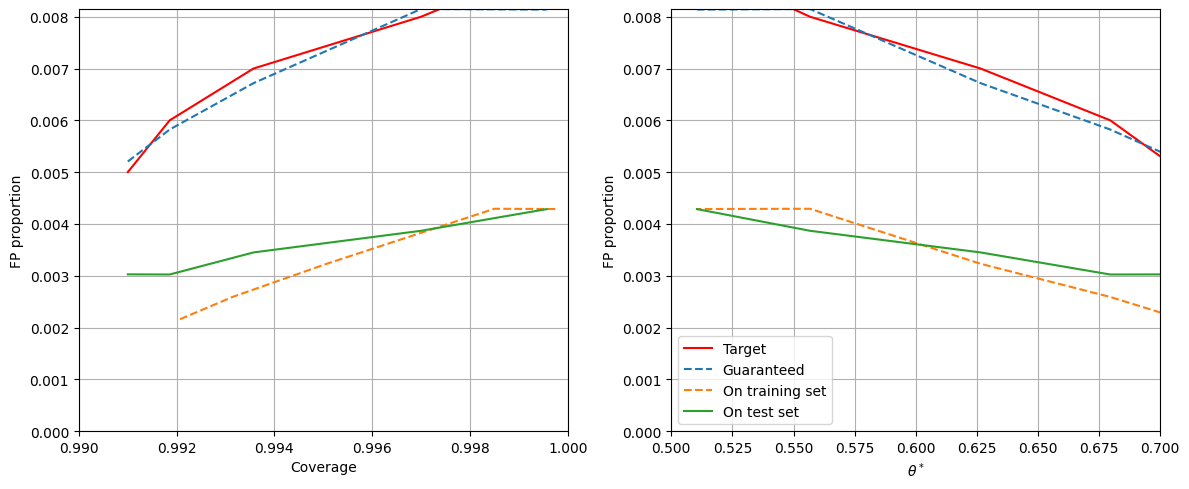

In [11]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FP', mode='dicho')
display(results)
metric_plots(results, ylabel='FP proportion', xlim1=[0.99,1], xlim2=[0.5,0.7], ylim=[0,max(results.metric_bound)])

__Comment__ : ~threefold increase of performance at the cost of -70% coverage
1) Best guaranteed performance (left) is ~2% of samples classified as FPs, cost is coverage =30%.
2) Baseline performance of classifier at 100% coverage would be ~10% of samples classified as FPs.

#### <font color = 'violet'> 2.1.2 Evolution of trade-offs as class imbalance increases

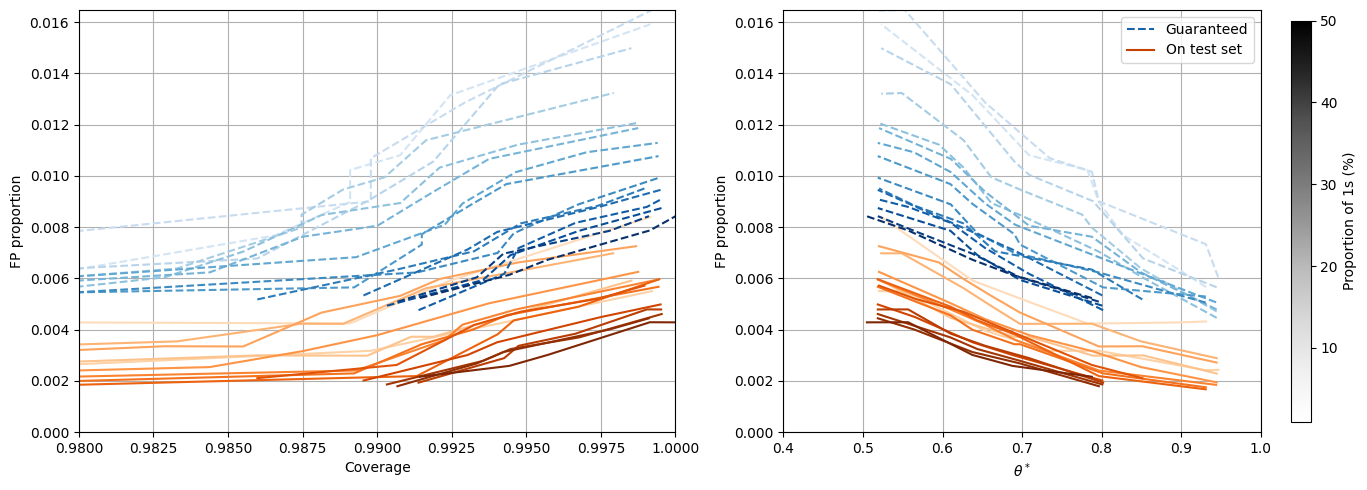

In [ ]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='dicho', metric='FP')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FP proportion', xlim1= [0.98, 1], xlim2= [0.4, 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)])

__Comment__ : one can observe that here less 1s means
* higher FP risk at fixed coverage (makes completely sense since there are relatively more 0s to commit mistakes on)
* steeper risk/coverage curves, ie more FP risk improvement from the same amount of coverage renouncement

__In other words, in this setting, higher class imbalance => Selection with Guaranteed FP Risk brings more benefits with the same amount of coverage renouncement__

### <font color = 'orange'> 2.2. __FN proportion control__

#### <font color = 'violet'> 2.2.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.004913,0.811749,0.001954,0.986927,0.001735,0.987575
1,0.006,0.005834,0.743588,0.002595,0.991213,0.001732,0.989717
2,0.007,0.007017,0.638820,0.003448,0.994642,0.002588,0.993145
3,0.008,0.008149,0.556714,0.004293,0.998500,0.003008,0.997001
4,0.009,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572
5,0.010,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572
6,0.011,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572
7,0.013,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572
8,0.016,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572
9,0.018,0.008139,0.510480,0.004287,0.999786,0.004715,0.999572


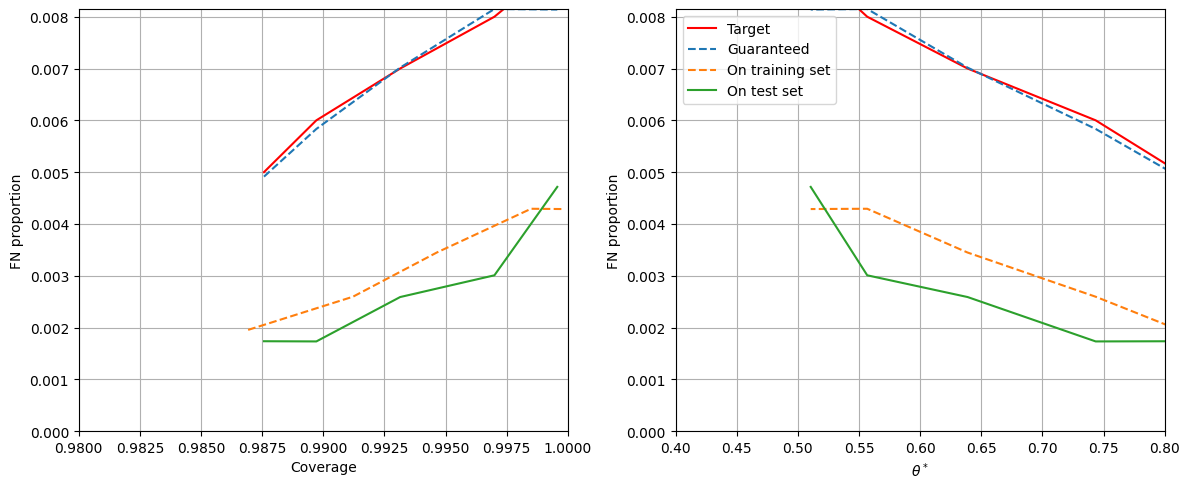

In [13]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FN', mode='dicho')
display(results)
metric_plots(results, ylabel='FN proportion', xlim1=[0.98,1], xlim2=[0.4,0.8], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 2.2.2 Evolution of trade-offs as class imbalance increases

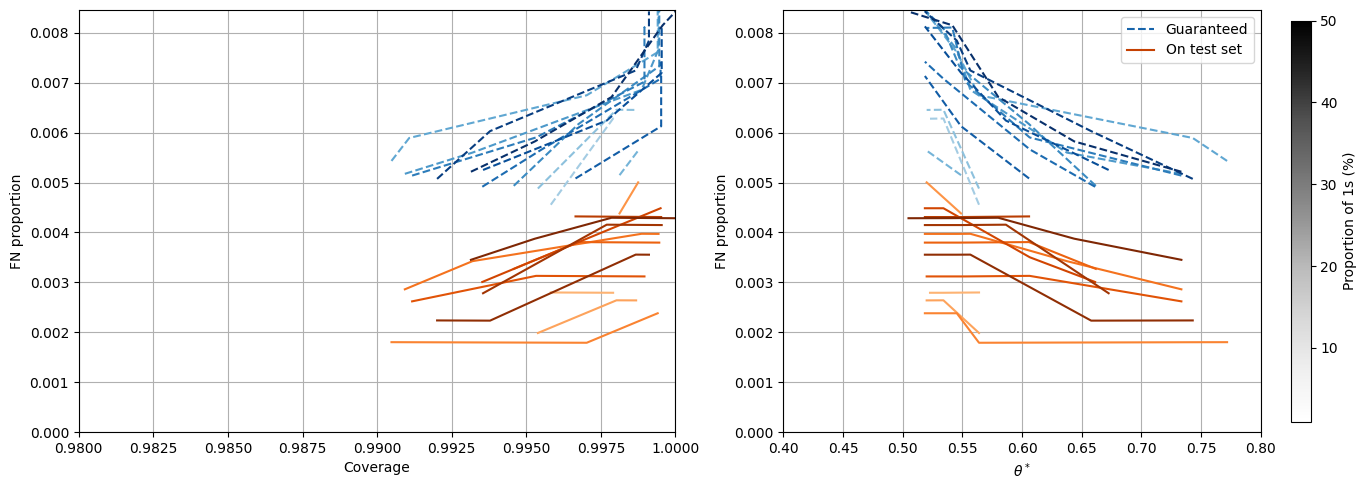

In [ ]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='dicho', metric='FN')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FN proportion', xlim1= [0.98, 1], xlim2= [0.4, 0.8],
                            ylim=[0,max(all_propor_dfs.metric_bound)])

## <font color = 'yellow'> 3. __Specific metrics control__

### <font color = 'orange'> 3.1. __FPR control__

#### <font color = 'violet'> 3.1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.004733,0.989880,0.000468,0.924775,0.000915,0.922022
1,0.006,0.006538,0.979761,0.001374,0.944278,0.000891,0.944730
2,0.007,0.007241,0.949402,0.001795,0.966995,0.000874,0.965296
3,0.008,0.008615,0.807728,0.002629,0.986927,0.004259,0.988003
4,0.009,0.009357,0.797608,0.003066,0.987570,0.004259,0.988432
5,0.010,0.010739,0.716652,0.003922,0.991856,0.005952,0.990574
6,0.011,0.011433,0.706532,0.004355,0.992070,0.005952,0.991003
7,0.013,0.013442,0.655934,0.005650,0.993999,0.005947,0.992716
8,0.016,0.015392,0.615456,0.006944,0.995285,0.006785,0.993573
9,0.018,0.017845,0.504141,0.008636,1.000000,0.009259,1.000000


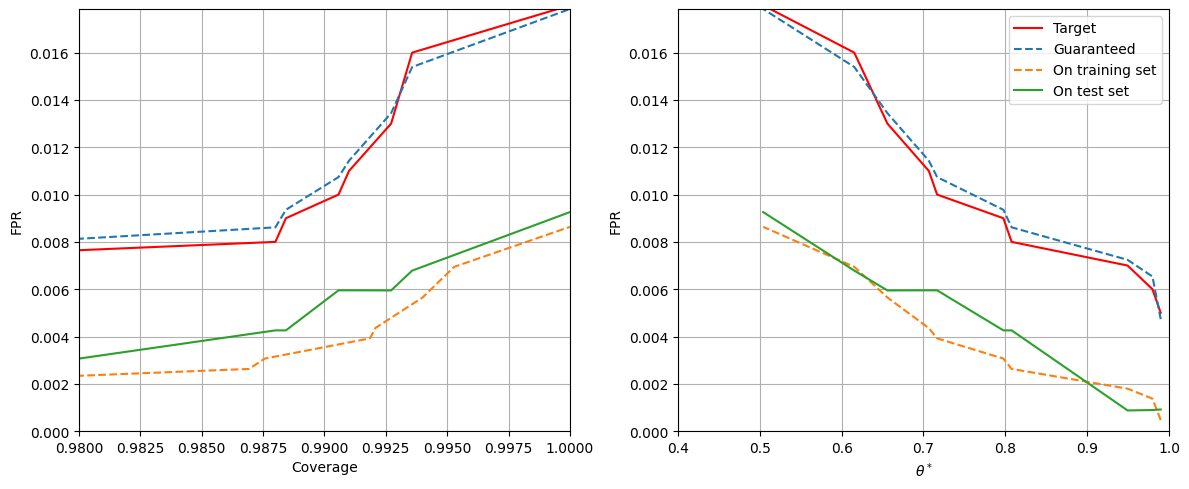

In [ ]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FPR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FPR', xlim1=[0.98,1], xlim2=[0.4,1], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 3.1.2. Evolution of trade-offs as class imbalance increases

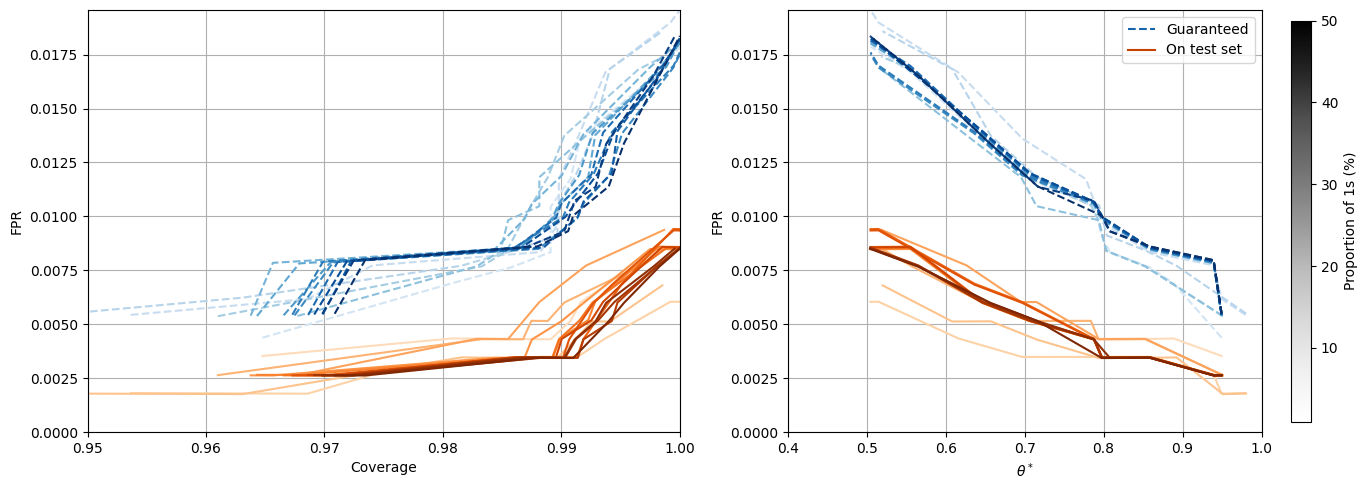

In [16]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='FPR')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FPR', xlim1= [0.95, 1], xlim2= [0.4, 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)])

### <font color = 'orange'> 3.2. __FNR control__

#### <font color = 'violet'> 3.2.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.006,0.006202,0.939282,0.001309,0.971496,0.000898,0.969580
1,0.007,0.007790,0.929163,0.002176,0.973639,0.000895,0.972579
2,0.008,0.008482,0.868445,0.002592,0.983069,0.003546,0.984147
3,0.009,0.009901,0.827967,0.003445,0.986284,0.003543,0.985861
4,0.010,0.010598,0.807728,0.003874,0.986927,0.003534,0.988003
5,0.011,0.011935,0.757130,0.004723,0.989927,0.003527,0.989717
6,0.013,0.013869,0.645815,0.005991,0.994213,0.005263,0.992716
7,0.016,0.016978,0.564858,0.008099,0.997857,0.006130,0.996144
8,0.018,0.017564,0.504141,0.008511,1.000000,0.009599,1.000000
9,0.022,0.017564,0.504141,0.008511,1.000000,0.009599,1.000000


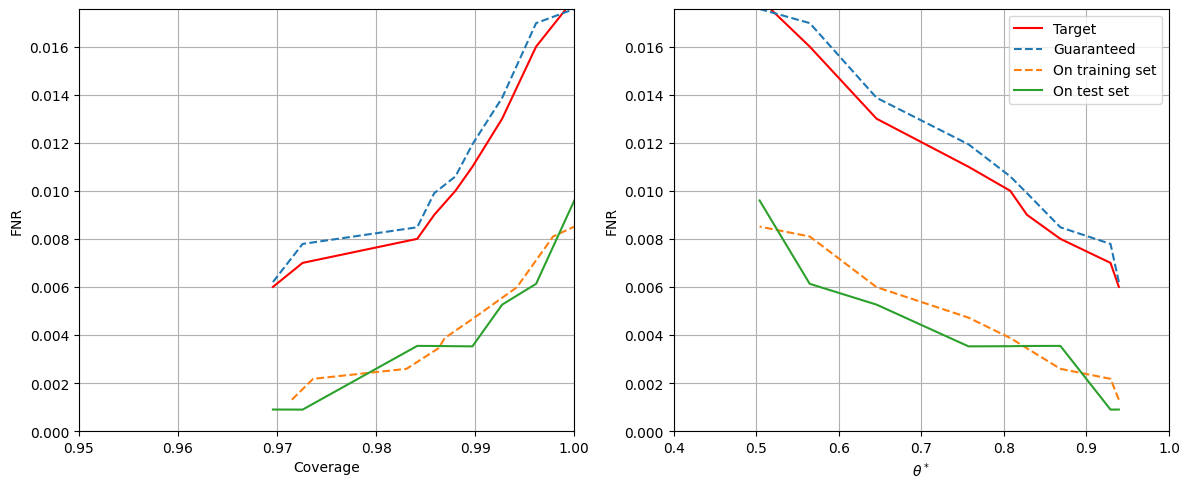

In [17]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FNR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FNR', xlim1=[0.95,1], xlim2=[0.4,1], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 3.2.2. Evolution of trade-offs as class imbalance increases

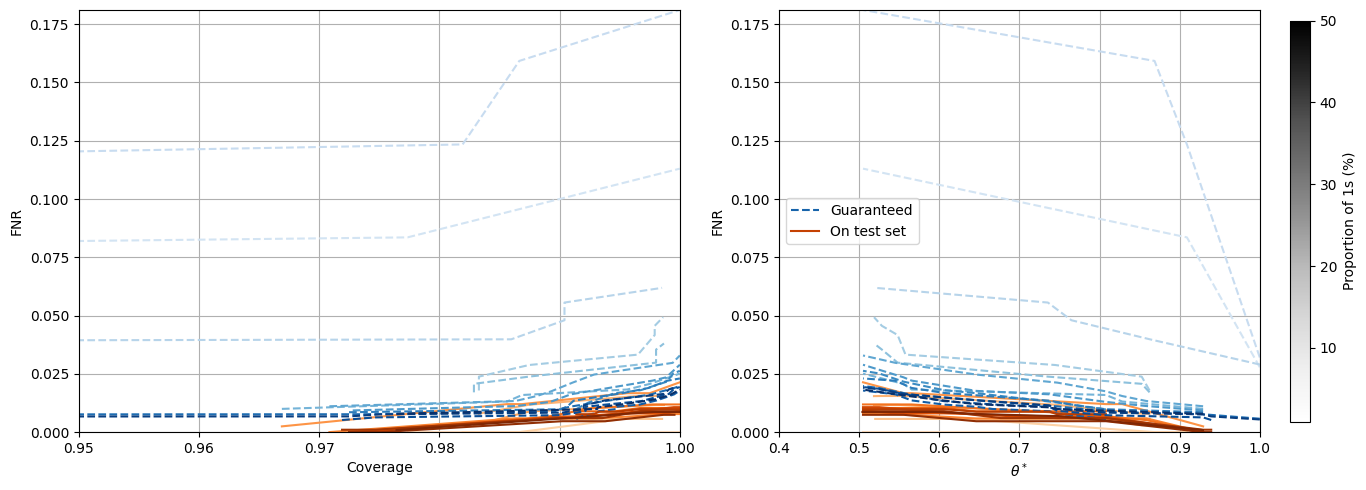

In [20]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='FNR')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FNR', xlim1= [0.95, 1], xlim2= [0.4, 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)])

### <font color = 'orange'> 3.3. __PPV control__

#### <font color = 'violet'> 3.3.1. Risk coverage trade-offs

In [21]:
metric_targets=[i/1000 for i in integers_log_spacing(700,1000)]

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
1,0.730,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
2,0.757,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
3,0.782,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
4,0.805,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
5,0.827,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
6,0.846,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
7,0.864,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
8,0.880,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
9,0.895,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000


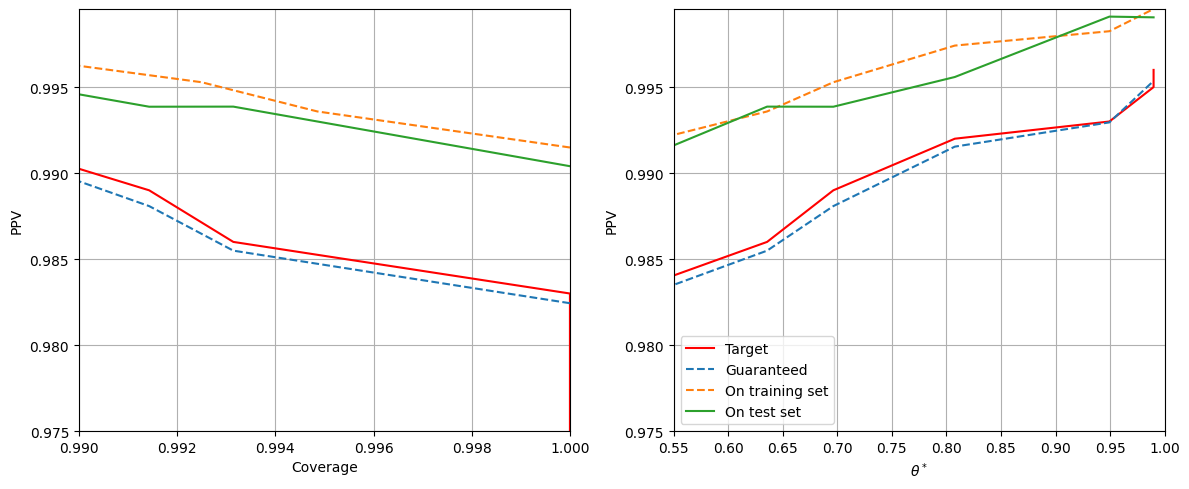

In [22]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'PPV', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='PPV', xlim1=[0.99,1], xlim2=[0.55,1], ylim=[0.975, max(results.train_metric)])

#### <font color = 'violet'> 3.3.2. Evolution of trade-offs as class imbalance increases

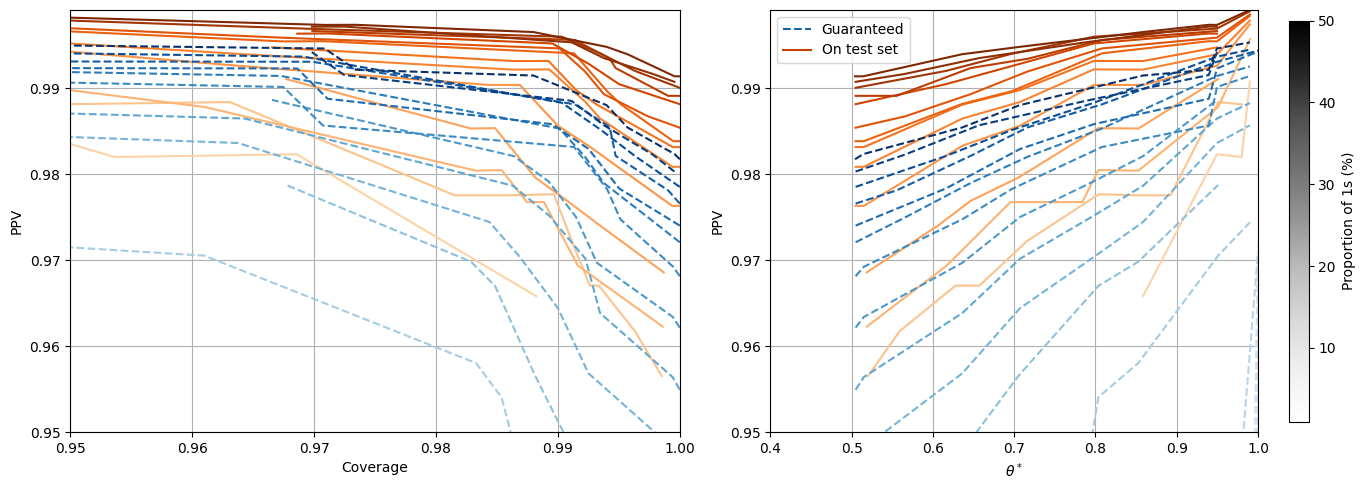

In [23]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='PPV')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='PPV', xlim1= [0.95, 1], xlim2= [0.4, 1],
                            ylim=[0.95,max(all_propor_dfs.test_metric)])

### <font color = 'orange'> 3.4. __SE control__

#### <font color = 'violet'> 3.4.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
1,0.730,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
2,0.757,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
3,0.782,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
4,0.805,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
5,0.827,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
6,0.846,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
7,0.864,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
8,0.880,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000
9,0.895,0.982436,0.504141,0.991489,1.000000,0.990401,1.000000


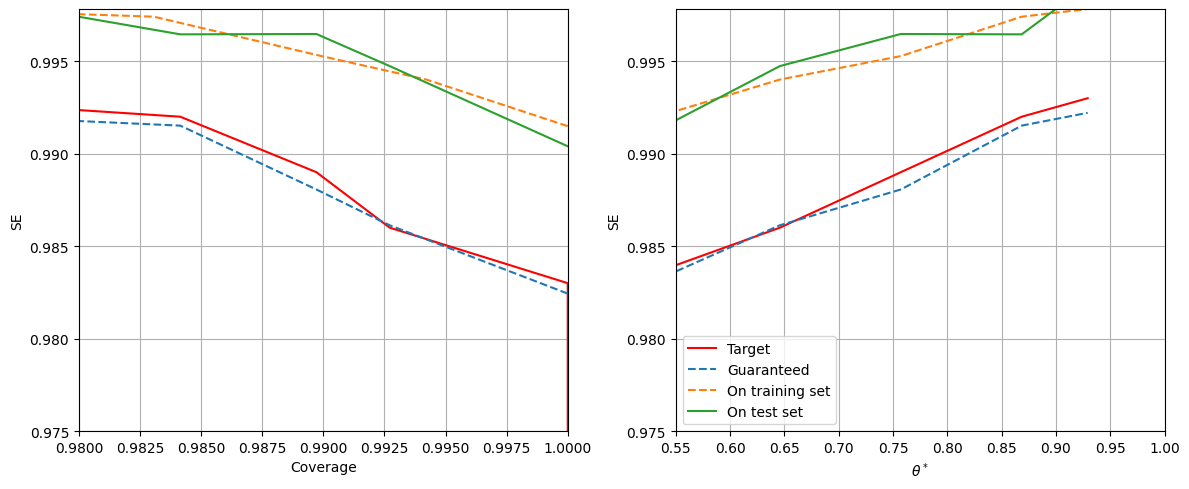

In [24]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SE', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SE', xlim1=[0.98,1], xlim2=[0.55,1], ylim=[0.975,max(results.train_metric)])

#### <font color = 'violet'> 3.4.2. Evolution of trade-offs as class imbalance increases

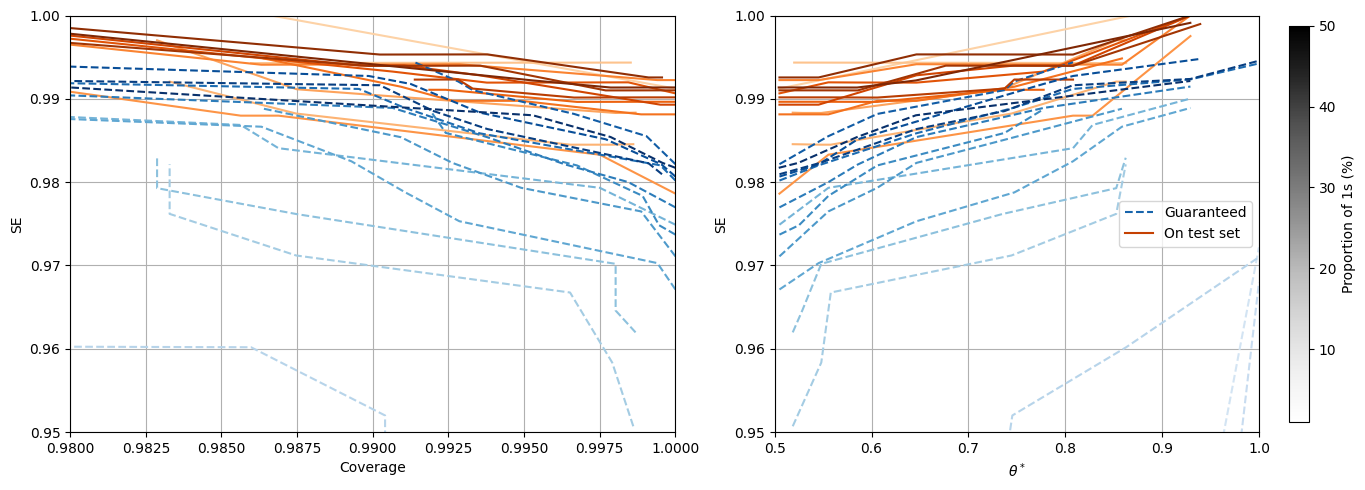

In [25]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='SE')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='SE', xlim1= [0.98, 1], xlim2= [0.5, 1],
                            ylim=[0.95,max(all_propor_dfs.test_metric)])

### <font color = 'orange'> 3.5. __SP control__

#### <font color = 'violet'> 3.5.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.700,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
1,0.730,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
2,0.757,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
3,0.782,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
4,0.805,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
5,0.827,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
6,0.846,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
7,0.864,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
8,0.880,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000
9,0.895,0.982155,0.504141,0.991364,1.000000,0.990741,1.000000


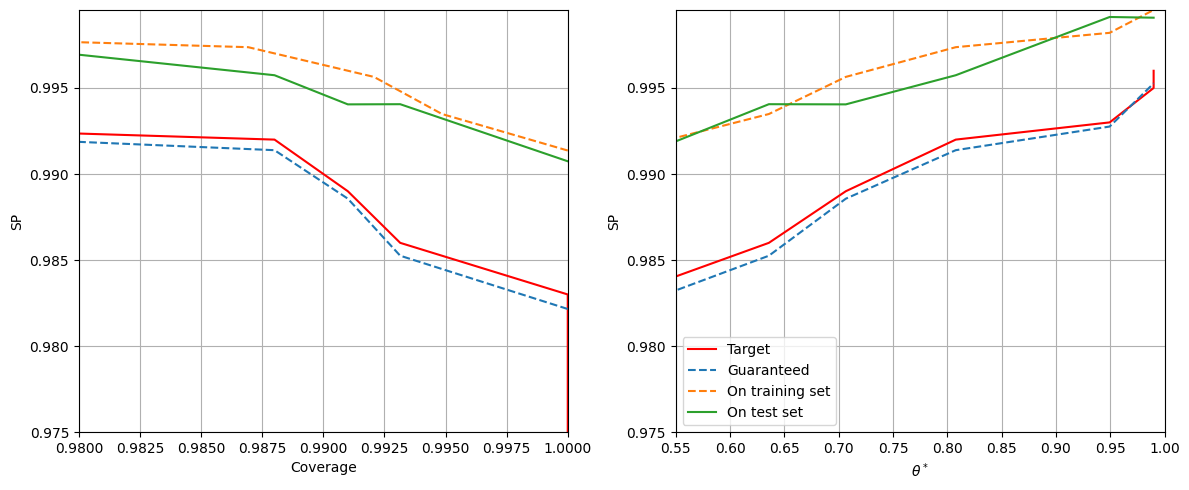

In [26]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SP', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SP', xlim1=[0.98,1], xlim2=[0.55,1], ylim=[0.975,max(results.train_metric)])

#### <font color = 'violet'> 3.5.2. Evolution of trade-offs as class imbalance increases

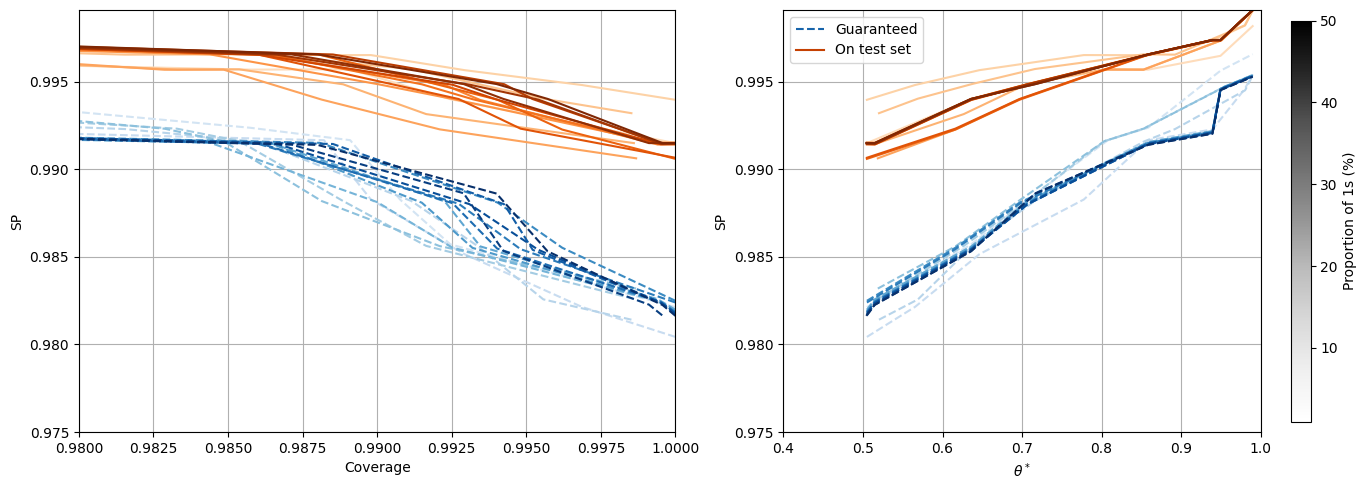

In [27]:
all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='SP')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='SP', xlim1= [0.98, 1], xlim2= [0.4, 1],
                            ylim=[0.975,max(all_propor_dfs.test_metric)])